### **Purpose:** perform eda

In [26]:
# this notebook is linked to prev one (01_merge_data) so anything imported there will work here (:

In [27]:
# target balance 
print("=== TARGET BALANCE ===")

val_counts = train_merged[target_col].value_counts()
pos_rate = train_merged[target_col].mean() * 100

print(f"Value Counts:\n{val_counts}")
print(f"Positive Rate (Class 1): {pos_rate:.2f}%\n")

=== TARGET BALANCE ===
Value Counts:
dryspell_warn_7d
0    1890
1     324
Name: count, dtype: int64
Positive Rate (Class 1): 14.63%



In [28]:
print("=== MISSINGNESS ===")
# % missing per column
missing_pct = train_merged.isna().mean() * 100
missing_cols = missing_pct[missing_pct > 0].sort_values(ascending=False)

# Rows with ANY missing data
rows_with_missing = train_merged.isna().any(axis=1).sum()
pct_rows_missing = (rows_with_missing / len(train_merged)) * 100

if len(missing_cols) == 0:
    print("Columns with missing data: None! 100% complete.")
else:
    print(f"Columns with missing data:\n{missing_cols}")
print(f"Rows with at least one missing value: {rows_with_missing} ({pct_rows_missing:.2f}%)\n")

=== MISSINGNESS ===
Columns with missing data: None! 100% complete.
Rows with at least one missing value: 0 (0.00%)



=== REDUNDANCY (Highly Correlated Pairs) ===
Flagged Pair: sea_level_pressure & surface_pressure (Corr: 0.9945)
Flagged Pair: sst_cameroon_mean_temperature_kelvin & sst_cameroon_mean_temperature_deg_c (Corr: 1.0000)
Flagged Pair: sst_indian_ocean_mean_temperature_kelvin & sst_indian_ocean_mean_temperature_deg_c (Corr: 1.0000)

=== STEP 4: RELEVANCE (Target Correlation) ===
Top 3 Positive Correlations:
 sst_cameroon_mean_temperature_kelvin    0.40
sst_cameroon_mean_temperature_deg_c     0.40
vapor_pressure_deficit                  0.28
Name: dryspell_warn_7d, dtype: float64

Top 3 Negative Correlations:
 5cm_soil_moist                                       -0.36
sst_cameroon_fraction_of_sea_ice_covered_ocean         NaN
sst_indian_ocean_fraction_of_sea_ice_covered_ocean     NaN
Name: dryspell_warn_7d, dtype: float64


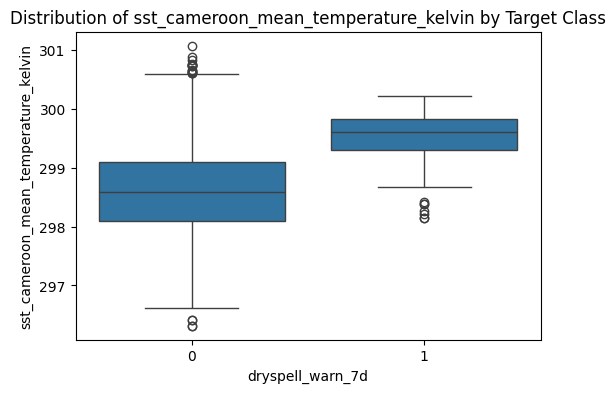

In [29]:
print("=== REDUNDANCY (Highly Correlated Pairs) ===")
# Get only numeric columns
num_cols = train_merged.select_dtypes(include=[np.number])
corr_matrix = num_cols.corr().abs()

# Extract upper triangle to avoid duplicating pairs like (A,B) and (B,A)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find pairs with correlation > 0.98
high_corr_pairs = [
    (upper_tri.index[i], upper_tri.columns[j], upper_tri.iloc[i, j])
    for i in range(upper_tri.shape[0]) for j in range(upper_tri.shape[1])
    if upper_tri.iloc[i, j] > 0.98
]

if not high_corr_pairs:
    print("No highly correlated pairs (> 0.98) found.")
else:
    for f1, f2, val in high_corr_pairs:
        print(f"Flagged Pair: {f1} & {f2} (Corr: {val:.4f})")



print("\n=== STEP 4: RELEVANCE (Target Correlation) ===")
# Correlation of features with the target
target_corr = num_cols.corr()[target_col].drop(target_col).sort_values(ascending=False)
print("Top 3 Positive Correlations:\n", target_corr.head(3))
print("\nTop 3 Negative Correlations:\n", target_corr.tail(3))

# Quick Boxplot for a top feature to visualize relevance
top_feature = target_corr.abs().idxmax()
plt.figure(figsize=(6, 4))
sns.boxplot(data=train_merged, x=target_col, y=top_feature)
plt.title(f'Distribution of {top_feature} by Target Class')
plt.show()


=== TIME SANITY (Seasonality & Drift) ===
month
7      0.00
8      0.00
9      9.26
10    49.10
Name: dryspell_warn_7d, dtype: float64


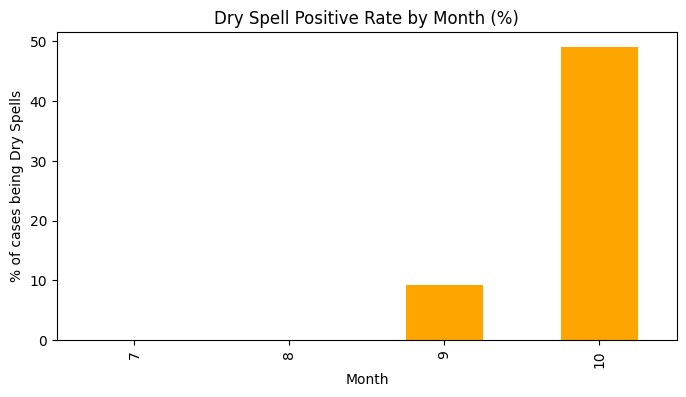

In [30]:
print("\n=== TIME SANITY (Seasonality & Drift) ===")
# Extract Year and Month
train_merged['year'] = train_merged['date'].dt.year
train_merged['month'] = train_merged['date'].dt.month

test_merged['year'] = test_merged['date'].dt.year
test_merged['month'] = test_merged['date'].dt.month

# Plot positive rate by month to check for seasonal dry spell patterns
monthly_rate = train_merged.groupby('month')[target_col].mean() * 100
print(monthly_rate)
plt.figure(figsize=(8, 4))
monthly_rate.plot(kind='bar', color='orange')
plt.title('Dry Spell Positive Rate by Month (%)')
plt.ylabel('% of cases being Dry Spells')
plt.xlabel('Month')
plt.show()


In [31]:
print("\n=== TRAIN/TEST DRIFT ===")

try:
    # Compare means of numeric features
    train_means = train_merged.select_dtypes(include=[np.number]).mean()
    test_means = test_merged.select_dtypes(include=[np.number]).mean()
    
    drift_df = pd.DataFrame({'Train_Mean': train_means, 'Test_Mean': test_means})
    # Calculate % difference
    drift_df['Pct_Diff'] = ((drift_df['Test_Mean'] - drift_df['Train_Mean']) / drift_df['Train_Mean'].replace(0, np.nan)) * 100
    
    # Sort by the absolute largest shifts
    drift_df['Abs_Diff'] = drift_df['Pct_Diff'].abs()
    drift_df = drift_df.sort_values(by='Abs_Diff', ascending=False).drop(columns=['Abs_Diff'])
    
    print("Features with the largest mean shifts between Train and Test:")
    print(drift_df.head(5))
except NameError:
    print("Could not run drift check: 'test_merged' is not defined yet.")


=== TRAIN/TEST DRIFT ===
Features with the largest mean shifts between Train and Test:
                         Train_Mean  Test_Mean  Pct_Diff
potential_water_deficit        0.12      -0.31   -351.03
u10                            0.35       0.51     48.41
5cm_soil_moist                 0.26       0.31     22.80
vapor_pressure_deficit         3.15       3.68     16.62
mean_dew_point_temp           20.16      18.66     -7.40
